## Project ML Year 4
### Prediction of Pruchase behavior of a product

#### 1. Import des bibliothèques

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

#### 2. Chargement et aperçu des données

In [18]:
DATA_PATH = 'Electronic_sales_Sep2023-Sep2024.csv' # chemin du CSV


df = pd.read_csv(DATA_PATH)
print(f"{df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

20000 lignes, 16 colonnes


,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


##### Descriptive Analysis of the Dataset

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes

,Customer ID,Age,Rating,Total Price,Unit Price,Quantity,Add-on Total
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10483.526550,48.994100,3.093950,3180.133418,578.631867,5.485550,62.244848
std,5631.732525,18.038745,1.223764,2544.978675,312.274076,2.870854,58.058431
min,1000.000000,18.000000,1.000000,20.750000,20.750000,1.000000,0.000000
25%,5478.000000,33.000000,2.000000,1139.680000,361.180000,3.000000,7.615000
50%,10499.500000,49.000000,3.000000,2534.490000,463.960000,5.000000,51.700000
75%,15504.000000,65.000000,4.000000,4639.600000,791.190000,8.000000,93.842500
max,19998.000000,80.000000,5.000000,11396.800000,1139.680000,10.000000,292.770000



=== Categorical Value Counts ===

--- Gender ---
Gender
Male      10164
Female     9835
Name: count, dtype: int64

--- Loyalty Member ---
Loyalty Member
No     15657
Yes     4343
Name: count, dtype: int64

--- Product Type ---
Product Type
Smartphone    5978
Tablet        4104
Laptop        3973
Smartwatch    3934
Headphones    2011
Name: count, dtype: int64

--- SKU ---
SKU
TBL345     2062
SKU1002    2042
SKU1004    2019
SKU1005    2012
HDP456     2010
SMP234     1987
SWT567     1980
SKU1001    1972
LTP123     1961
SKU1003    1955
Name: count, dtype: int64

--- Order Status ---
Order Status
Completed    13432
Cancelled     6568
Name: count, dtype: int64

--- Payment Method ---
Payment Method
Credit Card      5868
Bank Transfer    3371
PayPal           3284
Paypal           2514
Cash             2492
Debit Card       2471
Name: count, dtype: int64

--- Purchase Date ---
Purchase Date
2024-04-26    88
2024-07-02    85
2024-01-28    84
2024-04-20    83
2024-01-09    82
2024-08-10    81


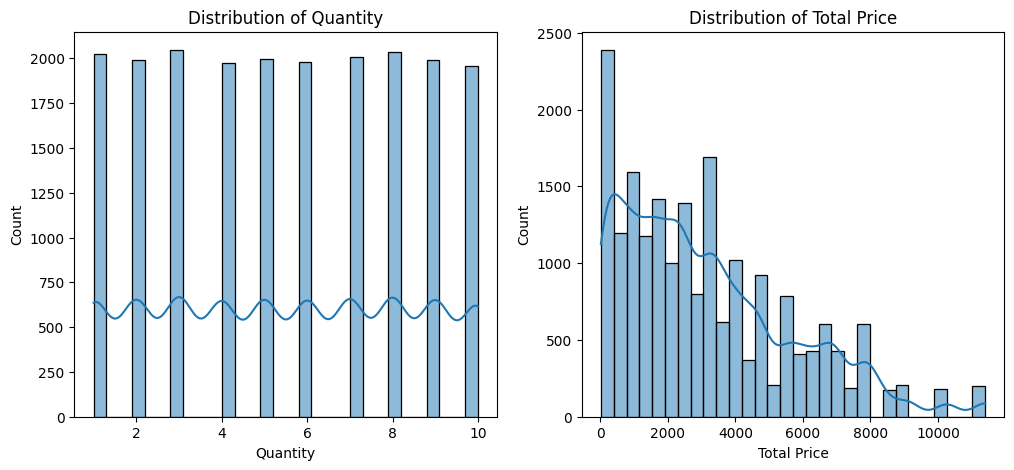

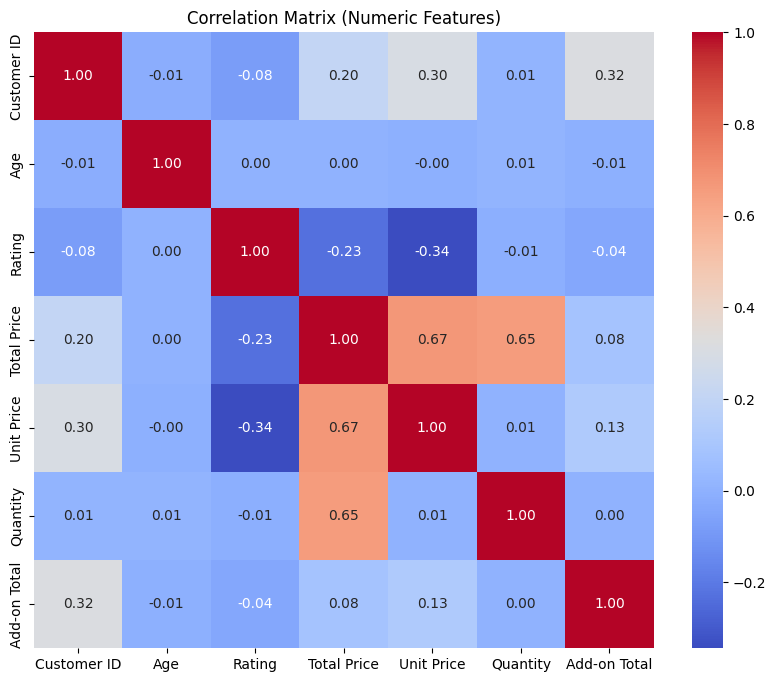

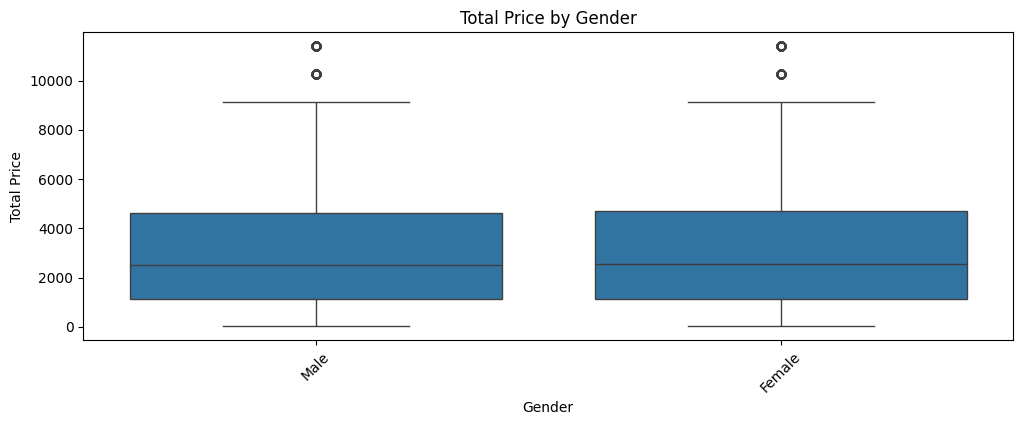

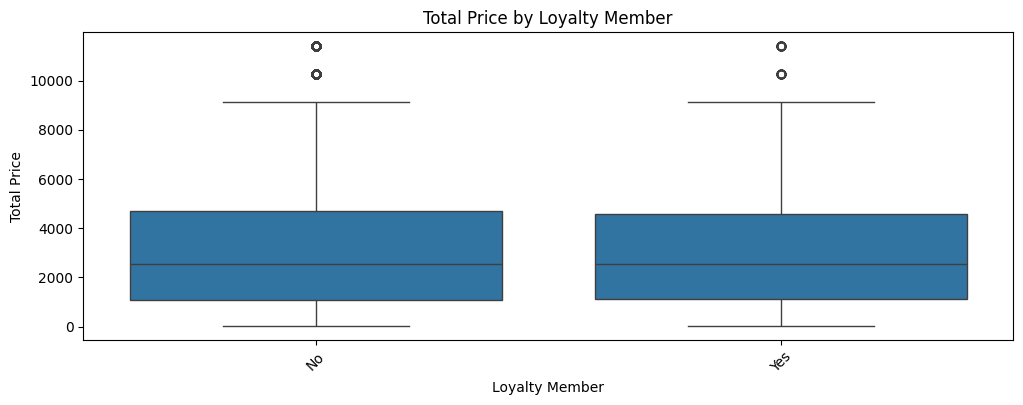

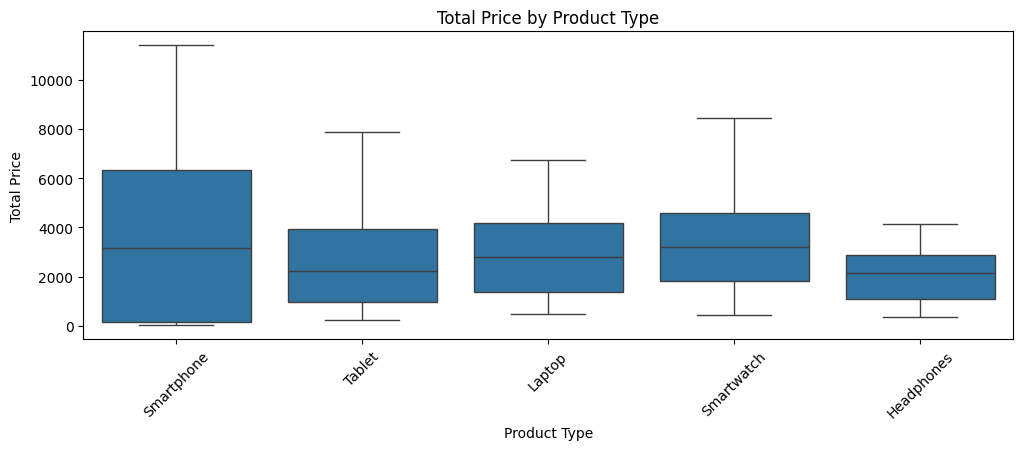

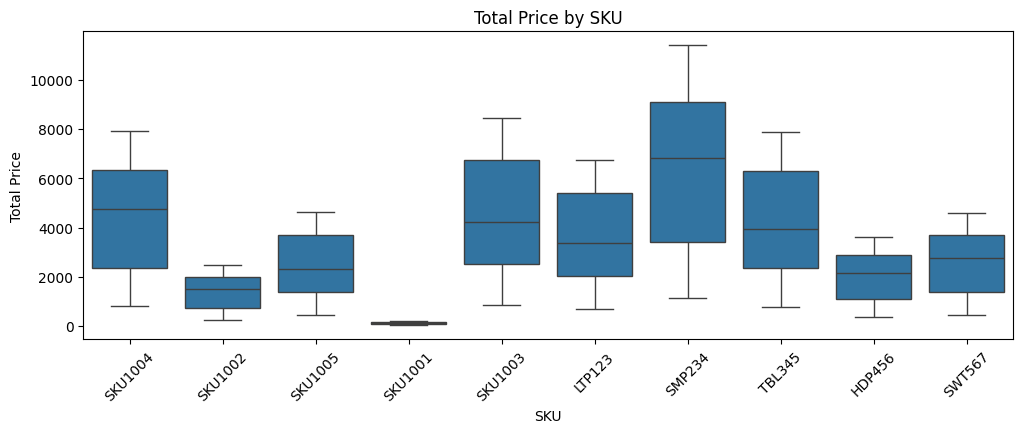

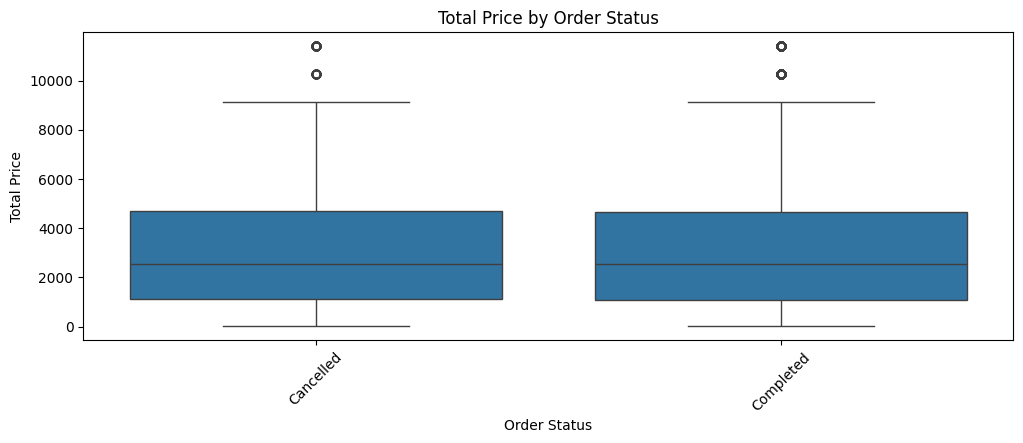

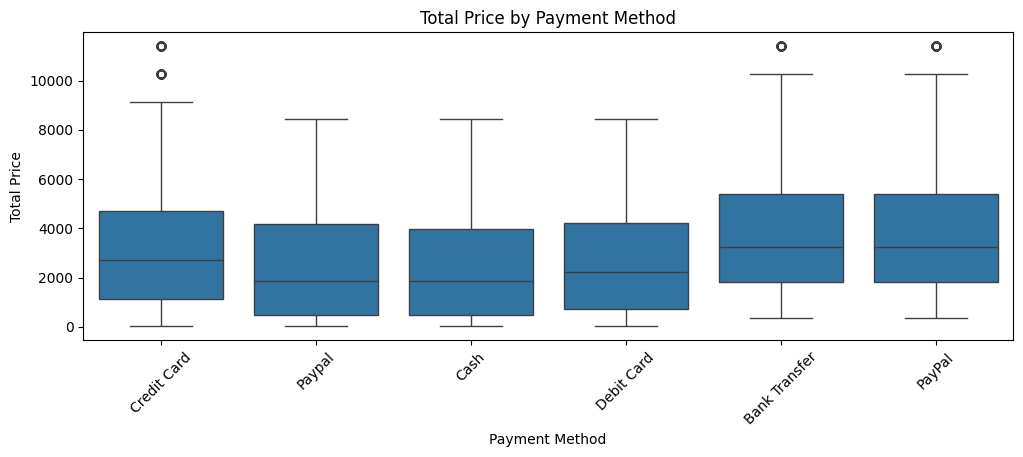

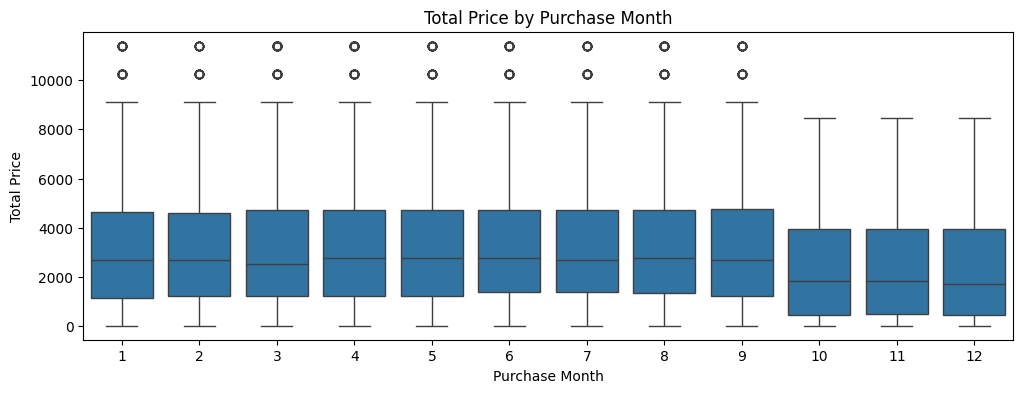

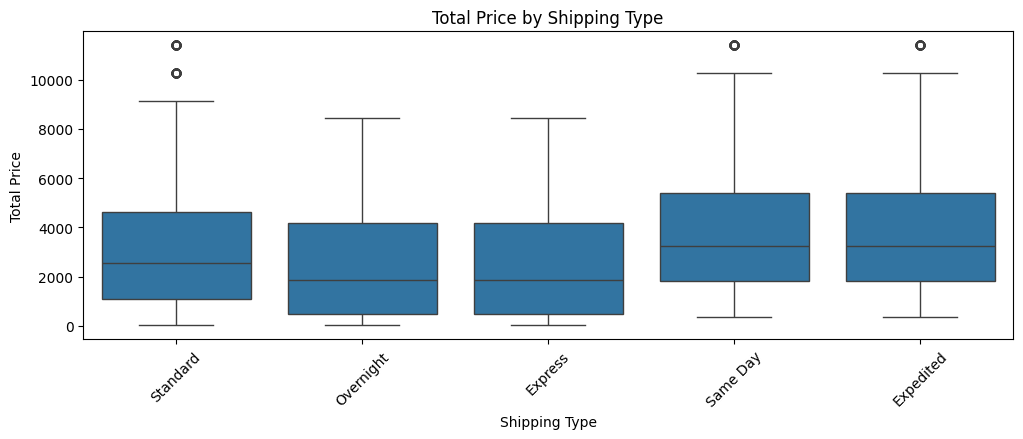

In [19]:
# 1️⃣ Basic info
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values per Column ===")
print(df.isnull().sum())

print("\n=== Summary Statistics (Numerical Columns) ===")
display(df.describe())

# 2️⃣ Check categorical value distributions
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print("\n=== Categorical Value Counts ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))  # show top 10 values

# 3️⃣ Target distribution (Quantity & Total Price)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title('Distribution of Quantity')

plt.subplot(1,2,2)
sns.histplot(df['Total Price'], bins=30, kde=True)
plt.title('Distribution of Total Price')
plt.show()

# 4️⃣ Correlation matrix for numeric features
num_cols = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

# 5️⃣ Additional: relationship between categorical and targets
for col in cat_cols:
    if col in df.columns and col != 'Add-ons Purchased':
        plt.figure(figsize=(12,4))
        if col == 'Purchase Date':
            # Extract month for plotting
            df['Purchase_Month'] = pd.to_datetime(df['Purchase Date'], errors='coerce').dt.month
            sns.boxplot(x='Purchase_Month', y='Total Price', data=df)
            plt.xlabel('Purchase Month')
            plt.title('Total Price by Purchase Month')
        else:
            sns.boxplot(x=col, y='Total Price', data=df)
            plt.xticks(rotation=45)
            plt.title(f'Total Price by {col}')
        plt.show()

#### 3. Feature engineering

In [20]:
# Conversion des dates
if 'Purchase Date' in df.columns:
    df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')
    df['Purchase_Month'] = df['Purchase Date'].dt.month
    df['Purchase_DayOfWeek'] = df['Purchase Date'].dt.dayofweek
else:
    df['Purchase_Month'] = np.nan
    df['Purchase_DayOfWeek'] = np.nan


# Add-ons: compter et total
if 'Add-ons Purchased' in df.columns:
    df['Addons_Count'] = df['Add-ons Purchased'].fillna('').apply(lambda x: 0 if x == '' else len([a for a in str(x).split(',') if a.strip()!='']))
else:
    df['Addons_Count'] = 0


df['Addon_Total'] = pd.to_numeric(df.get('Add-on Total', 0), errors='coerce').fillna(0)


# Colonnes cibles
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Total Price'] = pd.to_numeric(df['Total Price'], errors='coerce')

# Normaliser la colonne pour éviter des variations de casse (Completed, completed, etc.)
df['Order Status'] = df['Order Status'].astype(str).str.strip().str.lower()

# Séparer les deux ensembles
df_completed = df[df['Order Status'] == 'completed'].copy()
df_cancelled = df[df['Order Status'] == 'cancelled'].copy()

print(f"Total lignes: {len(df)}")
print(f" - Completed: {len(df_completed)}")
print(f" - Cancelled: {len(df_cancelled)}")

# Vérification rapide
df_completed['Order Status'].value_counts()

Total lignes: 20000
 - Completed: 13432
 - Cancelled: 6568


Order Status
completed    13432
Name: count, dtype: int64

##### Influence of columns analysis (for completed and cancelled orders)

Importance des features (ordre décroissant) :


,Importance
Customer ID,0.289480
Age,0.186282
Purchase_Month,0.116083
Purchase_DayOfWeek,0.091180
Payment Method,0.056101
Shipping Type,0.048401
Rating,0.046782
Unit Price,0.034019
Order Status,0.028455
Gender,0.027713


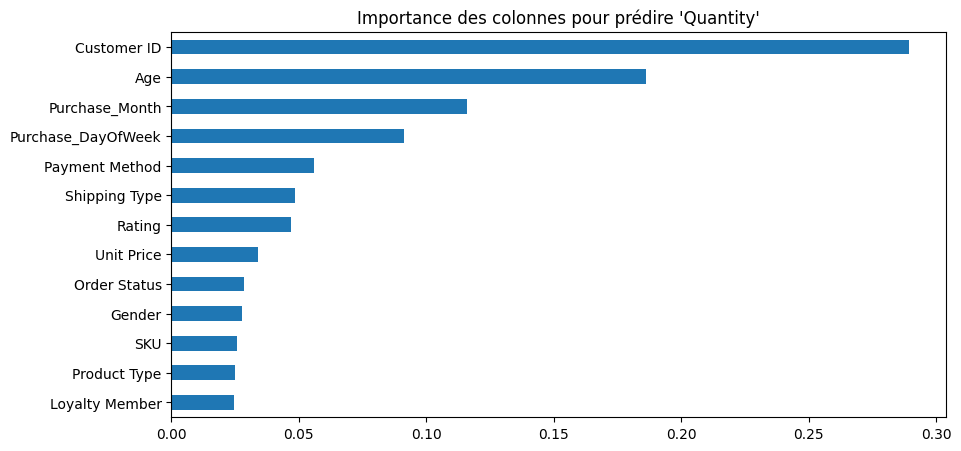

In [21]:
features_candidates = [
    'Customer ID', 'Order Status', 'Age', 'Gender', 'Loyalty Member', 'Product Type',
    'SKU', 'Rating', 'Payment Method', 'Unit Price',
    'Shipping Type', 'Purchase_Month', 'Purchase_DayOfWeek'
]

# Garder seulement celles présentes dans le dataset
features = [c for c in features_candidates if c in df.columns]

# Définir X et Y pour l’analyse
X = df[features].copy()
Y = df['Quantity']  # On se concentre sur Quantity

# Encodage simple des variables catégorielles
cat_cols = X.select_dtypes(include=['object', 'category']).columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = encoder.fit_transform(X[cat_cols])

# Remplacer les NaN par la médiane pour éviter les erreurs
X = X.fillna(X.median(numeric_only=True))

# Modèle rapide pour estimer l’importance
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, Y)

# Extraire les importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Importance des features (ordre décroissant) :")
display(importances.to_frame("Importance"))

# Visualisation
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importance des colonnes pour prédire 'Quantity'")
plt.show()

##### Sélection des Features Finales

For our problem we have the following information.
Our task is to predict the number of products bought by transactions.

Our X space is : 'SKU', 'Customer ID', 'Age', 'Rating', 'Unit Price', 'Purchase_Month', 'Purchase_DayOfWeek', 'Payment Method', 'Shipping Type'

Our Y space will be N, but we expect it to be between 1 and 20

Our model is a multi output regressor with random forest
We will reference our model on a polynomial

In [22]:
features_candidates = [
'SKU', 'Customer ID', 'Age', 'Rating', 'Unit Price', 'Purchase_Month', 
'Purchase_DayOfWeek', 'Payment Method', 'Shipping Type'
]


features = [c for c in features_candidates if c in df.columns]


df_model = df.dropna(subset=['Quantity', 'Total Price']).copy()
Y = df_model[['Quantity', 'Total Price']]
X = df_model[features]


X.head()

,SKU,Customer ID,Age,Rating,Unit Price,Purchase_Month,Purchase_DayOfWeek,Payment Method,Shipping Type
0,SKU1004,1000,53,2,791.19,3,2,Credit Card,Standard
1,SKU1002,1000,53,3,247.03,4,5,Paypal,Overnight
2,SKU1005,1002,41,3,463.96,10,1,Credit Card,Express
3,SKU1004,1002,41,2,791.19,8,4,Cash,Overnight
4,SKU1001,1003,75,5,20.75,5,1,Cash,Express


#### 4. Préparation du pipeline et séparation train/test

In [23]:
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns


num_transformer = Pipeline([
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler())
])


cat_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer([
('num', num_transformer, num_cols),
('cat', cat_transformer, cat_cols)
])


regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=42))
pipeline = Pipeline([
('preprocessor', preprocessor),
('regressor', regressor)
])


X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((16000, 9), (4000, 9))

#### 5. Entraînement du modèle

In [24]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 6. Évaluation du modèle

In [25]:
y_pred = pipeline.predict(X_test)


metrics = {}
for i, target in enumerate(['Quantity', 'Total Price']):
    y_true = y_test.values[:, i]
    y_p = y_pred[:, i]
    mae = mean_absolute_error(y_true, y_p)
    mse = mean_squared_error(y_true, y_p)
    rmse = np.sqrt(mse)  # ← manual RMSE
    r2 = r2_score(y_true, y_p)
    metrics[target] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

pd.DataFrame(metrics).T

,MAE,RMSE,R2
Quantity,2.530564,2.932744,-0.054538
Total Price,1447.696638,1921.847572,0.428319


#### 7. Aperçu des prédictions

In [26]:
comparison = X_test.reset_index(drop=True).copy()
comparison['Quantity_true'] = y_test.reset_index(drop=True)['Quantity']
comparison['TotalPrice_true'] = y_test.reset_index(drop=True)['Total Price']
comparison['Quantity_pred'] = y_pred[:, 0]
comparison['TotalPrice_pred'] = y_pred[:, 1]
comparison.head(10)

,SKU,Customer ID,Age,Rating,Unit Price,Purchase_Month,Purchase_DayOfWeek,Payment Method,Shipping Type,Quantity_true,TotalPrice_true,Quantity_pred,TotalPrice_pred
0,LTP123,11526,63,4,674.32,5,3,PayPal,Expedited,8,5394.56,6.035,4383.08000
1,SKU1002,2805,35,3,247.03,4,3,Debit Card,Standard,8,1976.24,4.550,1342.60805
2,SKU1003,8801,49,3,844.83,6,4,Paypal,Overnight,3,2534.49,4.685,3171.56590
3,SKU1004,1989,69,2,791.19,10,5,Debit Card,Express,7,5538.33,5.410,4781.13435
4,LTP123,14483,35,5,674.32,7,5,PayPal,Same Day,6,4045.92,5.355,3951.51520
5,LTP123,12677,66,5,674.32,2,5,PayPal,Expedited,6,4045.92,4.955,3149.07440
6,SWT567,11889,51,4,459.50,7,0,Credit Card,Standard,3,1378.50,5.700,2457.32090
7,SKU1001,3727,80,5,20.75,1,1,Debit Card,Express,7,145.25,4.670,97.31750
8,HDP456,19802,26,2,361.18,3,3,Bank Transfer,Expedited,4,1444.72,5.540,2120.12660
9,SKU1002,8292,38,3,247.03,3,0,Credit Card,Standard,9,2223.27,5.995,1614.34105


### Unsupervised Learning: Clustering Analysis


Data prepared for clustering: 20000 samples, 24 features


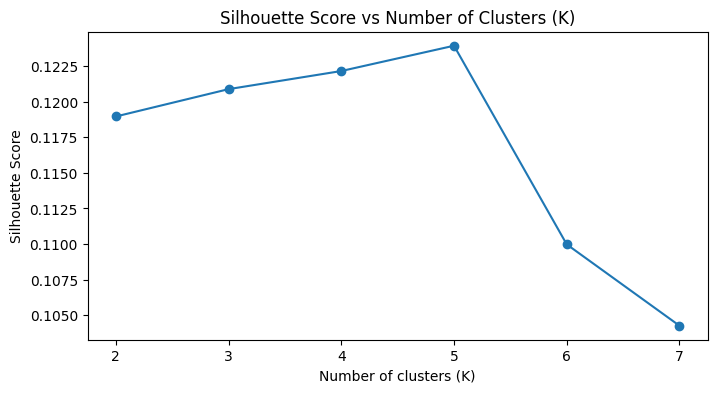

Best number of clusters based on silhouette score: 5

=== Cluster Summary ===


Sale_Amount                          Quantity    Age
               mean      min       max count     mean   mean
Cluster                                                     
0           3443.21   361.18   7977.76  3109     5.56  47.59
1           2401.82   247.03   6291.28  5659     4.67  32.44
2           2408.88   247.03   6291.28  5765     4.72  65.48
3           7385.04  3955.95  11396.80  3398     8.28  49.55
4            156.72    20.75   2279.36  2069     5.15  49.53

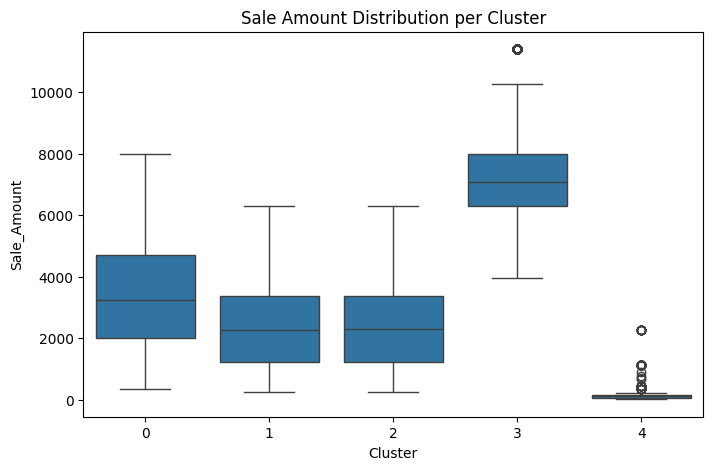

In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for clustering
df_cluster = df.copy()

# Create a 'Sale Amount' feature = Quantity × Unit Price
df_cluster['Sale_Amount'] = df_cluster['Quantity'] * df_cluster['Unit Price']

# Select meaningful clustering features
cluster_features = [
    'Age', 'Gender', 'Loyalty Member', 'Product Type', 'Payment Method',
    'Shipping Type', 'Rating', 'Sale_Amount'
]
cluster_features = [f for f in cluster_features if f in df_cluster.columns]
X = df_cluster[cluster_features].copy()

# Identify categorical vs numeric
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# Preprocessing: OneHot encode categoricals, scale numericals
ct = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

X_prep = ct.fit_transform(X)

print(f"Data prepared for clustering: {X_prep.shape[0]} samples, {X_prep.shape[1]} features")

# Find optimal K using silhouette score
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_prep)
    score = silhouette_score(X_prep, labels)
    sil_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8,4))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters (K)")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

# Pick best K
best_k = K_range[np.argmax(sil_scores)]
print(f"Best number of clusters based on silhouette score: {best_k}")

# Fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans_final.fit_predict(X_prep)

# Analyze clusters
cluster_summary = df_cluster.groupby('Cluster').agg({
    'Sale_Amount': ['mean', 'min', 'max', 'count'],
    'Quantity': 'mean',
    'Age': 'mean'
}).round(2)

print("\n=== Cluster Summary ===")
display(cluster_summary)

# Visualize Sale Amount per cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Sale_Amount', data=df_cluster)
plt.title('Sale Amount Distribution per Cluster')
plt.show()

#### Clusters Vizualisation

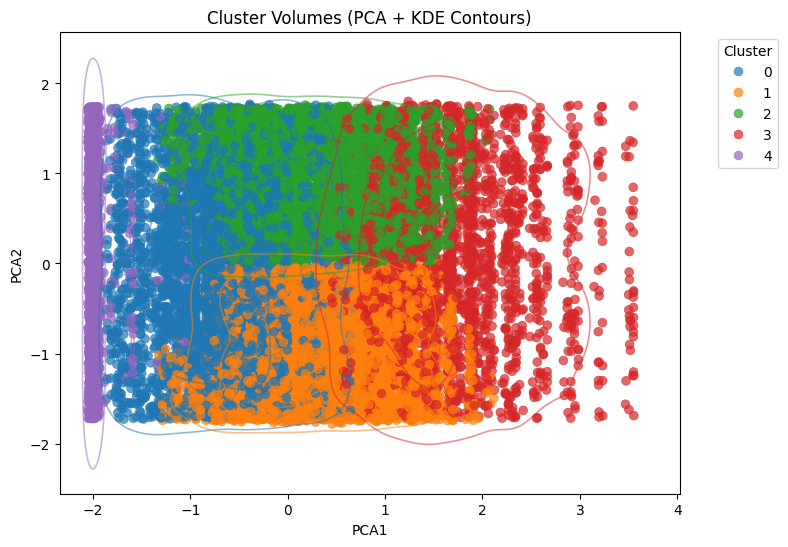

Explained variance by PCA axes: [0.201 0.161]


In [28]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prep)

df_viz = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_viz['Cluster'] = df_cluster['Cluster']

# %%
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    data=df_viz,
    palette='tab10',
    s=40, alpha=0.7, edgecolor=None
)

# Add kernel density estimate (KDE) contours per cluster
for c in sorted(df_viz['Cluster'].unique()):
    subset = df_viz[df_viz['Cluster'] == c]
    sns.kdeplot(
        data=subset,
        x='PCA1', y='PCA2',
        levels=3,  # number of contour lines
        color=sns.color_palette('tab10')[c],
        linewidths=1.2,
        alpha=0.5
    )

plt.title('Cluster Volumes (PCA + KDE Contours)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Variance explained by PCA axes
print("Explained variance by PCA axes:", np.round(pca.explained_variance_ratio_, 3))


In [30]:
pca.explained_variance_ratio_

array([0.20052302, 0.16110784])

#### Discretize Quantity and visualize on PCA plot

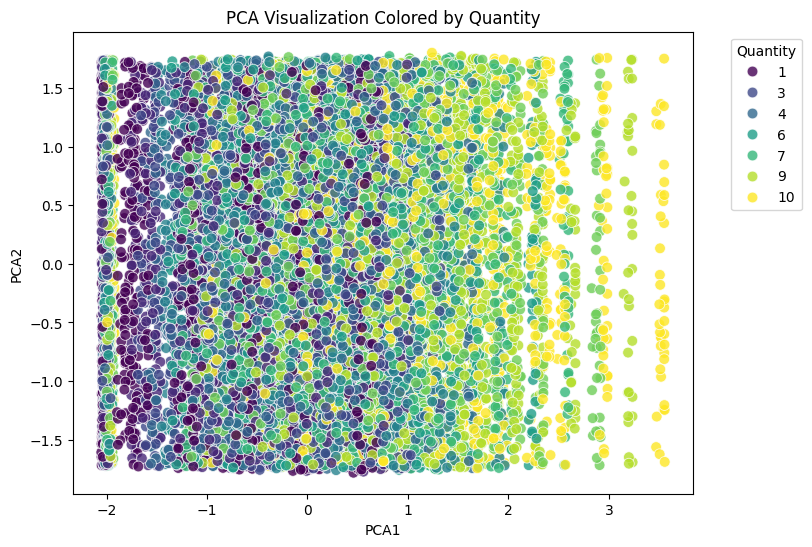

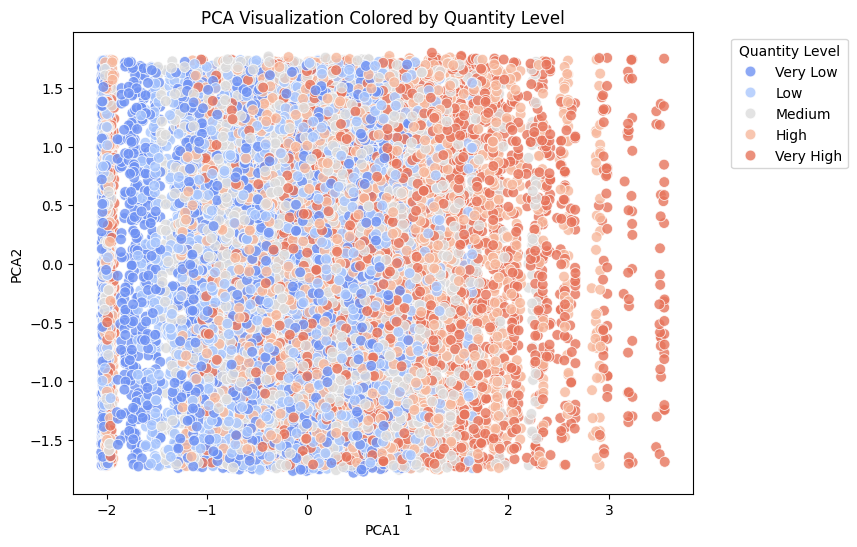

In [36]:
# 1️⃣ Discretize Quantity (into 3 bins: Low, Medium, High)
df_cluster['Quantity_Level'] = pd.qcut(
    df_cluster['Quantity'],
    q=5,
    labels=['Very Low','Low','Medium', 'High', 'Very High']
)

# 2️⃣ Compute PCA (2D)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prep)

df_viz = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_viz['Cluster'] = df_cluster['Cluster']
df_viz['Quantity'] = df_cluster['Quantity']
df_viz['Quantity_Level'] = df_cluster['Quantity_Level']

# 3️⃣ Visualization: color by Quantity (continuous)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_viz,
    x='PCA1', y='PCA2',
    hue='Quantity',
    palette='viridis',
    s=60,
    alpha=0.8
)
plt.title('PCA Visualization Colored by Quantity')
plt.legend(title='Quantity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 4️⃣ Visualization: color by Quantity Level (discretized)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_viz,
    x='PCA1', y='PCA2',
    hue='Quantity_Level',
    palette='coolwarm',
    s=60,
    alpha=0.8
)
plt.title('PCA Visualization Colored by Quantity Level')
plt.legend(title='Quantity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [31]:
pca.explained_variance_ratio_


array([0.20052302, 0.16110784])

#### Cluster Summary Analysis

In [32]:
# Compute aggregated metrics for each cluster
cluster_profile = df_cluster.groupby('Cluster').agg({
    'Quantity': 'mean',
    'Sale_Amount': 'mean',
    'Age': 'mean',
    'Rating': 'mean',
    'Loyalty Member': lambda x: x.value_counts(normalize=True).index[0],  # most common
    'Payment Method': lambda x: x.value_counts(normalize=True).index[0],
    'Product Type': lambda x: x.value_counts(normalize=True).index[0]
}).round(2)

cluster_profile.rename(columns={
    'Quantity': 'Avg_Quantity',
    'Sale_Amount': 'Avg_Sale',
    'Age': 'Avg_Age',
    'Rating': 'Avg_Rating',
    'Loyalty Member': 'Top_Loyalty_Status',
    'Payment Method': 'Top_Payment',
    'Product Type': 'Top_Product'
}, inplace=True)

display(cluster_profile)


,Avg_Quantity,Avg_Sale,Avg_Age,Avg_Rating,Top_Loyalty_Status,Top_Payment,Top_Product
Cluster,,,,,,,
0,5.56,3443.21,47.59,4.57,No,Bank Transfer,Tablet
1,4.67,2401.82,32.44,2.50,No,Credit Card,Laptop
2,4.72,2408.88,65.48,2.57,No,Credit Card,Laptop
3,8.28,7385.04,49.55,2.46,No,Credit Card,Smartphone
4,5.15,156.72,49.53,4.99,No,Credit Card,Smartphone


### Cluster Prediction

In [37]:
df_cluster['Cluster'] = kmeans_final.predict(X_prep)

In [38]:
# Features for training the classifier (same features used for clustering)
X_train = X_cluster_features = df_cluster[[
    'Age', 'Gender', 'Loyalty Member', 'Product Type', 
    'Payment Method', 'Shipping Type', 'Rating', 'Sale_Amount'
]].copy()

# Target = cluster labels
y_train = df_cluster['Cluster']


In [39]:
# Preprocess X_train (scale numeric, encode categorical)
X_train_prep = ct.transform(X_train)

In [40]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_prep, y_train)

# Optional: check training accuracy
y_pred_train = clf.predict(X_train_prep)
from sklearn.metrics import accuracy_score
print("Training accuracy:", accuracy_score(y_train, y_pred_train))

Training accuracy: 1.0
